# Temporal Analysis of IDEA Diagnoses

Data Downloaded from: https://data.ed.gov/dataset/idea-section-618-lea-part-b-child-count/resources?resource=0e0a1a55-57f5-4e50-b66e-1a68949e38f3

(2020-2022)

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from IDEA_loader import load_IDEA

In [13]:
# Just looking at school age children, so removing "Early Childhood"

IDEA_COLS_TO_DROP = [
    'Combined Early Childhood and School Age Total',
    'Early Childhood All Disabilities',
    'Early Childhood Autism',
    'Early Childhood Deaf-blindness',
    'Early Childhood Developmental Delay',
    'Early Childhood Emotional Disturbance',
    'Early Childhood Hearing Impairment',
    'Early Childhood Intellectual Disability',
    'Early Childhood Multiple Disabilities',
    'Early Childhood Orthopedic Impairment',
    'Early Childhood Other Health Impairment',
    'Early Childhood Specific Learning Disability',
    'Early Childhood Speech or Language Impairment',
    'Early Childhood Traumatic Brain Injury',
    'Early Childhood Visual Impairment',
    'Early Childhood Missing',
    
    # gives no information (all 0s)
    'School Age Missing'
]

IDEA_COL_MAPPING = {
    'School Age All Disabilities' : 'All Disabilites',
    'School Age Autism' : 'Autism',
    'School Age Deaf-blindness' : 'Deaf-blindness',
    'School Age Developmental Delay': 'Developmental Delay',
    'School Age Emotional Disturbance': 'Emotional Disturbance',
    'School Age Hearing Impairment' : 'Hearing Impariment',
    'School Age Intellectual Disability' : 'Intellectual Disability',
    'School Age Multiple Disabilities' : 'Multiple Disabilities',
    'School Age Orthopedic Impairment' : 'Orthopedic Impairment',
    'School Age Other Health Impairment' : 'Other Health Impairment',
    'School Age Specific Learning Disability': 'Specific Learning Disability',
    'School Age Speech or Language Impairment' : 'Speech or Language Impairment',
    'School Age Traumatic Brain Injury': 'Traumatic Brain Injury',
    'School Age Visual Impairment': 'Visual Impairment',

    'NCES LEA ID': 'LEAID'
}

NON_OBVIOUS_DISABILITIES = [
    'Autism',
    'Developmental Delay',
    'Emotional Disturbance',
    'Specific Learning Disability'
]

In [14]:
# combine multiple IDEA reports (2021-2023) into one dataframe.

# store the file names along with the amount of rows to skip at the top of each file.
files = {
    'bchildcountandedenvironmentlea2020-21.csv': 0,
    'bchildcountandedenvironmentlea2021-22.csv':4,
    'bchildcountdisabilitycategorylea2022-23.csv':4
}

dfs = [] 

for file_name in files.keys():
    rows_to_skip = files[file_name]

    df = load_IDEA(file_name,
                skip_rows=rows_to_skip,
                drop_columns=IDEA_COLS_TO_DROP,
                column_mappings=IDEA_COL_MAPPING
                )
    
    dfs.append(df)

idea_df = pd.concat(dfs, ignore_index=True)

c:\Projects\SEEN\paper_2\IDEA_loader.py:21: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, skiprows=skip_rows)


In [10]:
idea_df.head()

,School Year,State FIPS Code,State Name,LEA Name,State LEA ID,LEAID,All Disabilites,Autism,Deaf-blindness,Developmental Delay,Emotional Disturbance,Hearing Impariment,Intellectual Disability,Multiple Disabilities,Orthopedic Impairment,Other Health Impairment,Specific Learning Disability,Speech or Language Impairment,Traumatic Brain Injury,Visual Impairment
0,2020-2021,1,ALABAMA,Acceleration Day and Evening Academy,800,100197,50.0,5.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,17.0,23.0,0.0,0.0,NaN
1,2020-2021,1,ALABAMA,Al Inst Deaf And Blind,600,100009,332.0,0.0,3.0,0.0,0.0,166.0,NaN,59.0,0.0,0.0,0.0,NaN,0.0,101.0
2,2020-2021,1,ALABAMA,Alabama Clinical Schools,709,100183,39.0,NaN,0.0,0.0,5.0,0.0,3.0,NaN,0.0,12.0,14.0,NaN,0.0,0.0
3,2020-2021,1,ALABAMA,Alabama Youth Services,210,100002,17.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,4.0,8.0,NaN,0.0,0.0
4,2020-2021,1,ALABAMA,Alabaster City,103,100190,655.0,102.0,0.0,45.0,55.0,7.0,37.0,9.0,NaN,107.0,178.0,105.0,NaN,7.0


In [18]:
# pivot the table to combine rows for LEAs
index_cols = ['LEAID', 'LEA Name', 'State Name']
values_cols = NON_OBVIOUS_DISABILITIES
"""values_cols = ['All Disabilites', 'Autism', 'Deaf-blindness',
            'Developmental Delay', 'Emotional Disturbance', 'Hearing Impariment',
            'Intellectual Disability', 'Multiple Disabilities',
            'Orthopedic Impairment', 'Other Health Impairment',
            'Specific Learning Disability', 'Speech or Language Impairment',
            'Traumatic Brain Injury', 'Visual Impairment']"""

df_pivot = idea_df.pivot_table(
    index=index_cols,
    columns='School Year',
    values=values_cols
).reset_index()

# some magic to rename columns reasonably.
df_pivot.columns = index_cols + [f'{col[0]} {col[1]}' for col in df_pivot.columns[len(index_cols):]]

In [24]:
# create total columns
for year in ['2020-2021', '2021-2022', '2022-2023']:
    df_pivot['Total ' + year] = 0
    for dis in NON_OBVIOUS_DISABILITIES:
        df_pivot['Total ' + year] += df_pivot[dis + ' ' + year].fillna(0)

In [54]:
df_pivot['2021 Change'] = (df_pivot['Total 2021-2022'] - df_pivot['Total 2020-2021']) / (df_pivot['Total 2021-2022'] + df_pivot['Total 2020-2021'])
df_pivot['2022 Change'] = (df_pivot['Total 2022-2023'] - df_pivot['Total 2021-2022']) / (df_pivot['Total 2022-2023'] + df_pivot['Total 2021-2022'])


df_pivot['avg_change'] = (df_pivot['2021 Change'] + df_pivot['2022 Change']) / 2

In [55]:
df_pivot

,LEAID,LEA Name,State Name,Autism 2020-2021,Autism 2021-2022,Autism 2022-2023,Developmental Delay 2020-2021,Developmental Delay 2021-2022,Developmental Delay 2022-2023,Emotional Disturbance 2020-2021,...,Emotional Disturbance 2022-2023,Specific Learning Disability 2020-2021,Specific Learning Disability 2021-2022,Specific Learning Disability 2022-2023,Total 2020-2021,Total 2021-2022,Total 2022-2023,2021 Change,2022 Change,avg_change
0,100002,Alabama Youth Services,ALABAMA,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,8.0,11.0,9.0,8.0,11.0,9.0,0.157895,-0.100000,0.028947
1,100005,Albertville City,ALABAMA,32.0,39.0,38.0,18.0,23.0,29.0,5.0,...,3.0,145.0,167.0,168.0,200.0,238.0,238.0,0.086758,0.000000,0.043379
2,100006,Marshall County,ALABAMA,67.0,66.0,82.0,47.0,42.0,38.0,14.0,...,14.0,424.0,391.0,350.0,552.0,512.0,484.0,-0.037594,-0.028112,-0.032853
3,100007,Hoover City,ALABAMA,223.0,250.0,284.0,61.0,60.0,45.0,25.0,...,25.0,330.0,338.0,335.0,639.0,674.0,689.0,0.026657,0.011005,0.018831
4,100008,Madison City,ALABAMA,197.0,216.0,253.0,65.0,68.0,85.0,18.0,...,15.0,344.0,370.0,376.0,624.0,672.0,729.0,0.037037,0.040685,0.038861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17622,5900197,Noli School,BUREAU OF INDIAN EDUCATION,0.0,4.0,0.0,0.0,3.0,0.0,0.0,...,0.0,9.0,8.0,NaN,9.0,15.0,0.0,0.250000,-1.000000,-0.375000
17623,5900200,Jones Academy,BUREAU OF INDIAN EDUCATION,0.0,NaN,0.0,0.0,NaN,NaN,0.0,...,0.0,3.0,4.0,5.0,3.0,4.0,5.0,0.142857,0.111111,0.126984
17624,7200030,PUERTO RICO DEPARTMENT OF EDUCATION,PUERTO RICO,5809.0,6449.0,7763.0,0.0,0.0,0.0,1100.0,...,1022.0,36433.0,33064.0,35092.0,43342.0,40450.0,43877.0,-0.034514,0.040639,0.003063
17625,7800002,Saint Croix School District,U.S. VIRGIN ISLANDS,61.0,58.0,57.0,35.0,27.0,31.0,17.0,...,16.0,308.0,282.0,251.0,421.0,384.0,355.0,-0.045963,-0.039242,-0.042602


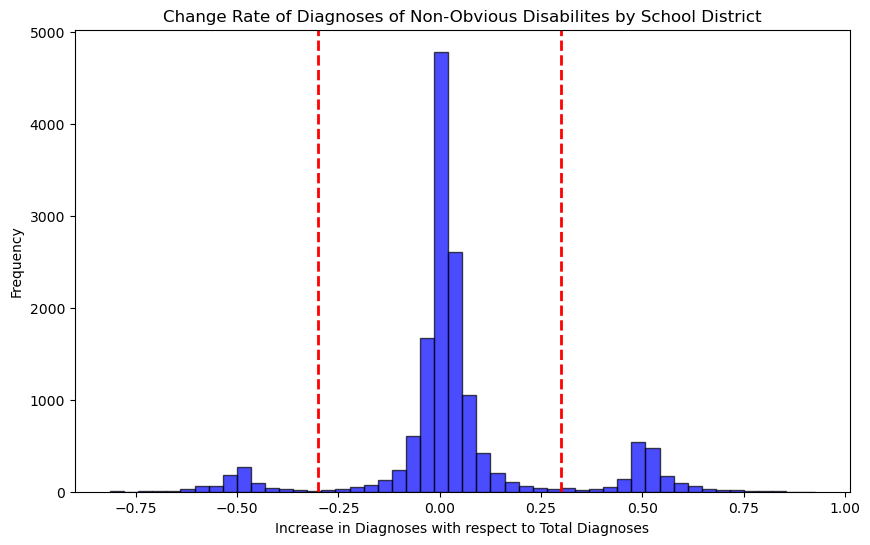

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df_pivot['avg_change'], bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(x=0.30, color='red', linestyle='--', linewidth=2)
plt.axvline(x=-0.30, color='red', linestyle='--', linewidth=2)
plt.title("Change Rate of Diagnoses of Non-Obvious Disabilites by School District")
plt.xlabel("Increase in Diagnoses with respect to Total Diagnoses")
plt.ylabel("Frequency")
plt.show()

In [78]:
conditions = [df_pivot['avg_change'] < -0.30, df_pivot['avg_change'] > 0.30]
choices = [-1, 1]
df_pivot['change_class'] = np.select(conditions, choices, default=0)

In [79]:
df_ohio = df_pivot[df_pivot['State Name'] == 'OHIO']
df_ohio[['LEAID', 'avg_change', 'change_class']].to_csv("processed_data/change_class.csv")